In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1、引入pandas库，是表格数据处理工具。
2、引入numpy库，提供高效的数组运算和数学函数。
3、引入matplotlib库，用来做可视化。
4、引入seaborn库。进行高级的可视化。

In [47]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.ensemble import RandomForestRegressor

1、导入四个线性回归模型：普通的线性回归，岭回归，套索回归，弹性网络。
2、导入随机森林回归模型。

In [48]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

1、导入执行交叉验证，绘制学习曲线，划分数据集的函数。
2、导入对数据进行标准化处理的工具。
3、导入管道构建函数。
4、导入均方误差计算函数。

In [49]:
import warnings
warnings.filterwarnings("ignore")

导入 Python 的警告模块。忽略所有警告信息。在训练过程中，某些模型（如 Lasso、ElasticNet）可能会因不收敛或数值问题产生警告，忽略它们可保持输出界面整洁，避免干扰分析思路。

In [50]:
SEED=42
np.random.seed(SEED)

定义和设置随机种子。

In [51]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')
print(f'训练集形状：{train.shape}，测试集形状：{test.shape}')
train.head()

训练集形状：(1460, 81)，测试集形状：(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


加载训练集与测试集
查看训练集前五行数据确认数据集加载正确。

In [52]:
test_id=test['Id']
y_train=train['SalePrice']
train_features=train.drop(['Id','SalePrice'],axis=1)
test_features=test.drop(['Id'],axis=1)
all_data=pd.concat([train,test],ignore_index=True)
print(f'合并后数据集形状：{all_data.shape}')

合并后数据集形状：(2919, 81)


保存测试集的Id和训练集的目标变量，纵向合并训练集和测试集并检查形状。

In [53]:
missing_counts=all_data.isnull().sum()
missing_counts[missing_counts>0].sort_values(ascending=False)
all_data['LotFrontage']=all_data['LotFrontage'].fillna(all_data['LotFrontage'].median())
all_data['MasVnrArea']=all_data['MasVnrArea'].fillna(0)
garage_num_cols=['GarageYrBlt','GarageArea','GarageCars']
for col in garage_num_cols:
    all_data[col]=all_data[col].fillna(0)
bsmt_num_cols=['BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath']
for col in bsmt_num_cols:
    all_data[col]=all_data[col].fillna(0)
categorical_fill_none=[
'Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2','FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature']
for col in categorical_fill_none:
    all_data[col]=all_data[col].fillna('None')
all_data['Electrical']=all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])
feature_cols_only=[col for col in all_data.columns if col!='SalePrice']
remaining_missing=all_data[feature_cols_only].isnull().sum().sum()
print(f'剩余缺失值数量：{all_data.isnull().sum().sum()}')

剩余缺失值数量：1471


此为手动填充缺失值，由结果可知，我们填充了大量的缺失值，但仍然存在一些细节的缺失值没有填充

In [54]:
from sklearn.impute import SimpleImputer
all_data_features=all_data[feature_cols_only].copy()
cols_with_nan=all_data_features.columns[all_data_features.isna().any()].tolist()
print(f'以下{len(cols_with_nan)}列仍存在缺失值{cols_with_nan}')
num_cols_with_nan=[col for col in cols_with_nan if all_data_features[col].dtype in ['int64','float64']]
cat_cols_with_nan=[col for col in cols_with_nan if all_data_features[col].dtype in ['object']]
if num_cols_with_nan:
    imputer_num=SimpleImputer(strategy='median')
    all_data_features[num_cols_with_nan]=imputer_num.fit_transform(all_data_features[num_cols_with_nan])
    print(f'已用中位数填充{num_cols_with_nan}')
if cat_cols_with_nan:
    imputer_cat=SimpleImputer(strategy='most_frequent')
    all_data_features[cat_cols_with_nan]=imputer_cat.fit_transform((all_data_features[cat_cols_with_nan]))
    print(f'已用众数填充{cat_cols_with_nan}')
print(f'特征列剩余缺失值总数{all_data_features.isna().sum().sum()}')
all_data=pd.concat([
    all_data[['Id','SalePrice']],
    all_data_features
],axis=1)
print(f'整个数据集剩余缺失值总数：{all_data.isna().sum().sum()}(其中SalePrice缺失{all_data['SalePrice'].isna().sum()}个,正常)')

以下7列仍存在缺失值['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
已用众数填充['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
特征列剩余缺失值总数0
整个数据集剩余缺失值总数：1459(其中SalePrice缺失1459个,正常)


采用SimpleImputer自动填充：数值列填中位数；类别列填众数。并在次确认整个数据集的缺失值情况。

In [55]:
len_train=train.shape[0]
X_all=all_data.drop(columns=['Id','SalePrice'])
y_all_sale=all_data['SalePrice']
X_train=X_all.iloc[:len_train]
y_train_from_all=y_all_sale.iloc[:len_train]
X_test=X_all.iloc[len_train:]
print(f"训练特征形状：{X_train.shape},测试特征形状：{X_test.shape}")
print(f"训练目标形状：{y_train_from_all.shape}")

训练特征形状：(1460, 79),测试特征形状：(1459, 79)
训练目标形状：(1460,)


拆分特征与目标，准备后续建模
4、提取训练集特征和标签。
6、测试集特征。

In [56]:
X_all=all_data.drop(columns=['Id','SalePrice'])
cat_cols=X_all.select_dtypes(include=['object']).columns.tolist()
num_cols=X_all.select_dtypes(include=['int64','float64']).columns.tolist()
print(f"类别特征数量：{len(cat_cols)}")
print(f"数值特征数量：{len(num_cols)}")
print(f"类别特征示例(前5个)：{cat_cols[:5]}")

类别特征数量：43
数值特征数量：36
类别特征示例(前5个)：['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour']


在合并后的数据集中区分两种特征：
（1）类别特征
（2）数值特征

In [57]:
X_encoded=pd.get_dummies(X_all,columns=cat_cols,drop_first=True)
print(f"编码前特征数:{X_all.shape[1]}")
print(f"编码后特征数:{X_encoded.shape[1]}")
print(f"数据集形状:{X_encoded.shape}")

编码前特征数:79
编码后特征数:259
数据集形状:(2919, 259)


线性模型和神经网络无法直接处理字符串，需要将每个类别转换为二进制向量。

In [58]:
from scipy.stats import skew
for col in num_cols:
    if col not in X_encoded.columns:
        print(f"警告:{col} 不在编码后数据中")
skew_vals=X_encoded[num_cols].apply(lambda x: skew(x.dropna()))
high_skew=skew_vals[abs(skew_vals)>0.75].index
print(f"高偏斜数值特征数:{len(high_skew)}")
print(f"例如: {high_skew[:5].tolist()}")
X_encoded[high_skew]=X_encoded[high_skew].apply(lambda x: np.log1p(x))
print("对数变换完成。")

高偏斜数值特征数:23
例如: ['MSSubClass', 'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1']
对数变换完成。


很多数值特征（如 `LotArea`, `GrLivArea`）呈右偏分布，不利于线性模型。
我们对偏斜度（skewness）大于某个阈值（通常 0.75）的特征施加 `log(1+x)` 变换。
注意：`log1p` 解决了零值问题（log(0) 无定义）。
算编码后所有数值特征的偏斜度
注意: 编码后特征全是数值，但我们需要区分原始数值特征（不是哑变量）
更简单：直接对编码后的所有特征计算偏斜度，但哑变量（0/1）的偏斜一般不高，变换影响很小。
稳妥做法：只对原始数值特征（即 num_cols）进行偏斜检查，然后对它们在编码后的列做变换。
确认 num_cols 在编码后仍然存在（它们是原始列，未参与编码）

In [59]:
y_all=all_data['SalePrice']
len_train=train.shape[0]
y_train_log=np.log1p(y_all.iloc[:len_train])
print(f"变换后训练目标前5个值:{y_train_log.head()}")

变换后训练目标前5个值:0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: SalePrice, dtype: float64


房价分布通常也是右偏的，对 `SalePrice` 取对数可以使其更接近正态分布，提升模型性能。从 all_data 中取出 SalePrice（注意：这是原始值，包含训练集和测试集，测试集部分为 NaN）

In [60]:
X_train_encoded=X_encoded.iloc[:len_train]
X_test_encoded=X_encoded.iloc[len_train:]
print(f"训练特征形状:{X_train_encoded.shape}")
print(f"测试特征形状:{X_test_encoded.shape}")
print(f"训练目标形状:{y_train_log.shape}")

训练特征形状:(1460, 259)
测试特征形状:(1459, 259)
训练目标形状:(1460,)


待补

In [61]:
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer
def rmse(y_true,y_pred):
    return np.sqrt(mean_squared_error(y_true,y_pred))
rmse_scorer=make_scorer(rmse,greater_is_better=False)
print("RMSE 指标定义完成")

RMSE 指标定义完成


1、导入K折交叉验证的分割器（后续用于交叉验证循环）。
2、用于将自定义的评分函数转化为 scorer 对象。
3、定义 RMSE 计算公式，调用已导入的 mean_squared_error 并取平方根。
4、包装后，交叉验证会返回负的 RMSE（因为 sklearn 默认最大化指标，我们需要最小化 RMSE，所以取负）。后续使用时取负即可得到正的 RMSE。

In [62]:
models={
    'LinearRegression':LinearRegression(),
    'Ridge':Ridge(alpha=1.0,random_state=SEED),
    'Lasso':Lasso(alpha=1.0,random_state=SEED),
    'ElasticNet':ElasticNet(alpha=1.0,l1_ratio=0.5,random_state=SEED),
    'RandomForest':RandomForestRegressor(n_estimators=100,random_state=SEED),
}
kfold=KFold(n_splits=5,shuffle=True,random_state=SEED)
results=[]
print("正在进行交叉验证 \n")
for name,model in models.items():
    if name=='RandomForest':
        pipeline=model
    else:
        pipeline=make_pipeline(StandardScaler(),model)
    scores=cross_val_score(pipeline,X_train_encoded,y_train_log,cv=kfold,scoring=rmse_scorer,n_jobs=-1)
    rmse_scores=-scores
    mean=rmse_scores.mean()
    std=rmse_scores.std()
    results.append((name,mean,std))
    print(f"{name:20s}:RMSE={mean:.5f} (±{std:.5f})")
results.sort(key=lambda x:x[1])
print("\n模型排名（RMSE升序）：")
for i,(name,mean,std) in enumerate(results,1):
    print(f"{i}.{name:20s}:{mean:.5f}(±{std:.5f})")

正在进行交叉验证 

LinearRegression    :RMSE=0.14621 (±0.01213)
Ridge               :RMSE=0.14945 (±0.01943)
Lasso               :RMSE=0.39878 (±0.02513)
ElasticNet          :RMSE=0.39878 (±0.02513)
RandomForest        :RMSE=0.14662 (±0.01923)

模型排名（RMSE升序）：
1.LinearRegression    :0.14621(±0.01213)
2.RandomForest        :0.14662(±0.01923)
3.Ridge               :0.14945(±0.01943)
4.Lasso               :0.39878(±0.02513)
5.ElasticNet          :0.39878(±0.02513)


2、普通线性回归，无任何正则化，容易过拟合且对多重共线性敏感。
3、L2正则化，惩罚系数的平方和，可以有效缩小系数但不将其变为零。
4、L1正则化，惩罚系数的绝对值，可以将部分系数压缩为零，实现特征选择。
5、结合L1和L2，l1_ratio=0.5表示一半L1、一半L2惩罚。
6、集成100棵决策树，对非线性关系和非交互作用适应性强。

In [63]:
best_pipeline=make_pipeline(StandardScaler(),LinearRegression())
best_pipeline.fit(X_train_encoded,y_train_log)
y_pred_log=best_pipeline.predict(X_test_encoded)
final_pred=np.expm1(y_pred_log)
print("预测完成，共",len(final_pred),"个样本。")

预测完成，共 1459 个样本。


LinearRegression 表现最佳（RMSE=0.14621）使用全量训练数据重新训练，并对测试集预测。

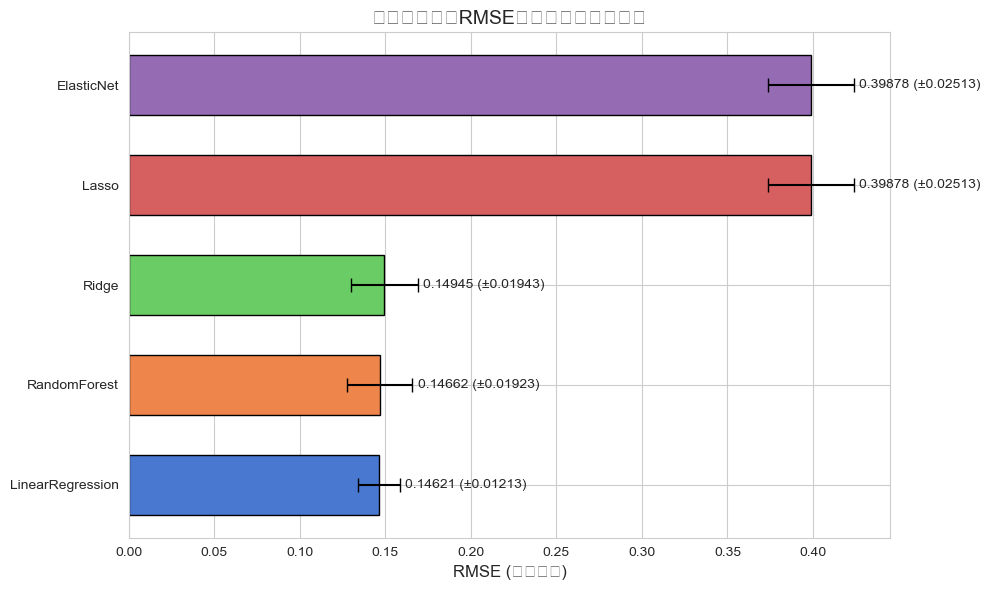

模型对比图已保存为 model_comparison_seaborn.png


In [64]:
df_results=pd.DataFrame(results,columns=['Model','RMSE','Std'])
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")
x_pos=np.arange(len(df_results))   # 柱状图位置
bars=plt.barh(x_pos,df_results['RMSE'],xerr=df_results['Std'],
              color=sns.color_palette("muted",len(df_results)),
              edgecolor='black',capsize=5,height=0.6)
plt.yticks(x_pos,df_results['Model'])
plt.xlabel('RMSE (对数空间)',fontsize=12)
plt.title('模型交叉验证RMSE对比（值越小越好）', fontsize=14)
for i,(mean,std) in enumerate(zip(df_results['RMSE'], df_results['Std'])):
    plt.text(mean+std+0.003,i,f'{mean:.5f} (±{std:.5f})',va='center',fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison_seaborn.png',dpi=150)
plt.show()
print("模型对比图已保存为 model_comparison_seaborn.png")

In [65]:
submission=pd.DataFrame({'Id':test_id,'SalePrice':final_pred})
submission.to_csv('submission.csv',index=False)
print("提交文件已生成：submission.csv")
print("\n前5行预览：")
print(submission.head())

提交文件已生成：submission.csv

前5行预览：
     Id      SalePrice
0  1461  121460.441005
1  1462  164876.272649
2  1463  188888.023092
3  1464  201610.608247
4  1465  199120.702388
